In [1]:
# Exploratory Data Analysis for Cocoa Disease Detection
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from PIL import Image
from tqdm import tqdm

In [8]:
# Load the dataset
train_df = pd.read_csv('/Users/victoroko/Documents/cocoa-disease-detection/data/raw/Train.csv')
test_df = pd.read_csv('/Users/victoroko/Documents/cocoa-disease-detection/data/raw/Test.csv')
images_dir = '/Users/victoroko/Documents/cocoa-disease-detection/data/annotations/dataset/images/train/'

# Display sample data
print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)
train_df.head()

Training data shape: (9792, 9)
Test data shape: (1626, 9)


,Image_ID,class,confidence,ymin,xmin,ymax,xmax,class_id,ImagePath
0,ID_nBgcAR.jpg,healthy,1.0,75.0,15.0,162.0,195.0,2,dataset/images/train/ID_nBgcAR.jpg
1,ID_nBgcAR.jpg,healthy,1.0,58.0,1.0,133.0,171.0,2,dataset/images/train/ID_nBgcAR.jpg
2,ID_nBgcAR.jpg,healthy,1.0,42.0,29.0,377.0,349.0,2,dataset/images/train/ID_nBgcAR.jpg
3,ID_Kw2v8A.jpg,healthy,1.0,112.0,124.0,404.0,341.0,2,dataset/images/train/ID_Kw2v8A.jpg
4,ID_Kw2v8A.jpg,healthy,1.0,148.0,259.0,413.0,412.0,2,dataset/images/train/ID_Kw2v8A.jpg


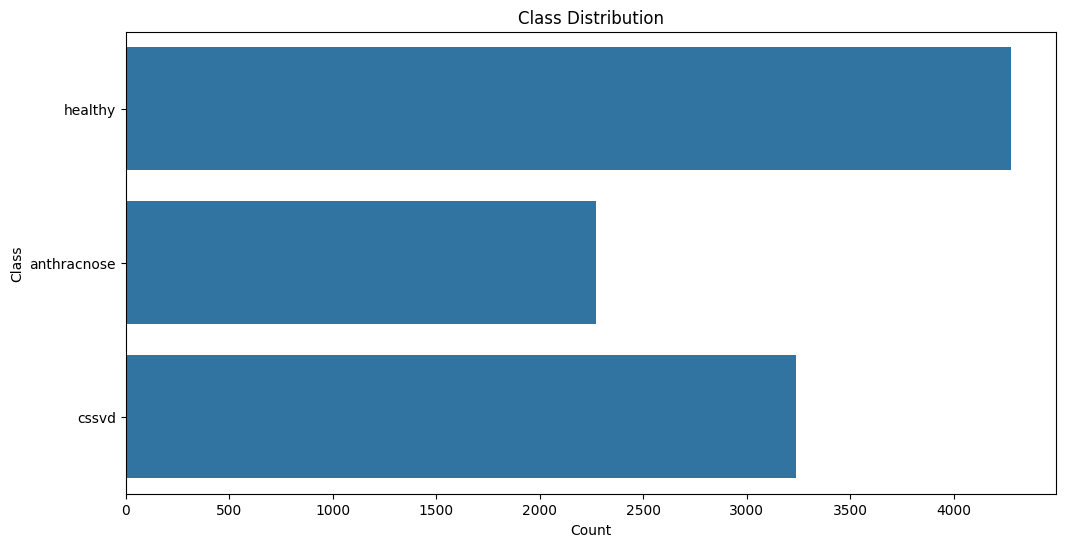

In [9]:
# Examine class distribution
plt.figure(figsize=(12, 6))
sns.countplot(y=train_df['class'])
plt.title('Class Distribution')
plt.xlabel('Count')
plt.ylabel('Class')
plt.show()

In [10]:
# Count images with multiple classes
img_class_counts = train_df.groupby('Image_ID')['class'].nunique()
img_with_multiple_classes = img_class_counts[img_class_counts > 1].count()
print(f"Images with multiple classes: {img_with_multiple_classes} ({img_with_multiple_classes / len(img_class_counts):.2%})")


Images with multiple classes: 6 (0.11%)


In [11]:
# Analyze image dimensions
img_dimensions = []
sample_size = min(500, len(train_df['Image_ID'].unique()))
sampled_images = np.random.choice(train_df['Image_ID'].unique(), sample_size, replace=False)

for img_id in tqdm(sampled_images):
    img_path = os.path.join(images_dir, img_id)
    try:
        img = cv2.imread(img_path)
        height, width, _ = img.shape
        img_dimensions.append((img_id, width, height))
    except Exception as e:
        print(f"Error processing {img_id}: {e}")

dimensions_df = pd.DataFrame(img_dimensions, columns=['Image_ID', 'width', 'height'])

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:32<00:00, 15.37it/s]


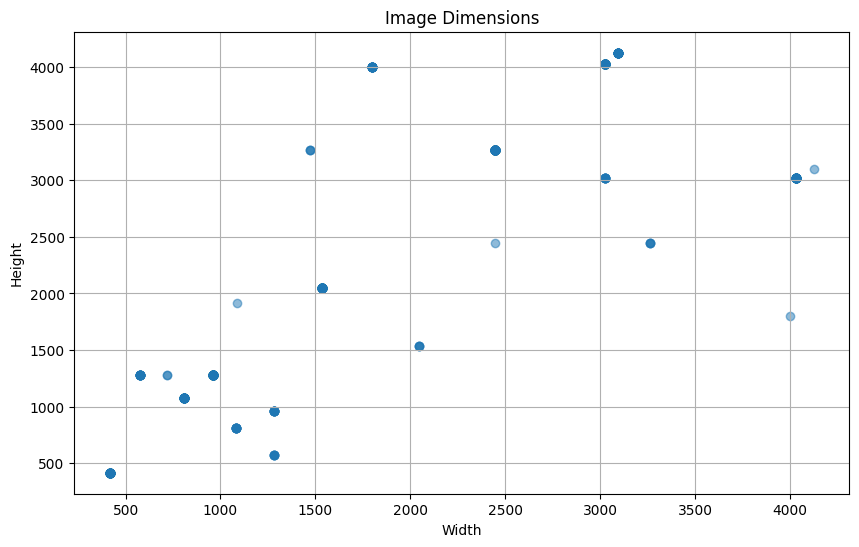

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(dimensions_df['width'], dimensions_df['height'], alpha=0.5)
plt.title('Image Dimensions')
plt.xlabel('Width')
plt.ylabel('Height')
plt.grid(True)
plt.show()

In [13]:
# Analyze bounding box sizes
train_df['box_width'] = train_df['xmax'] - train_df['xmin']
train_df['box_height'] = train_df['ymax'] - train_df['ymin']
train_df['box_area'] = train_df['box_width'] * train_df['box_height']

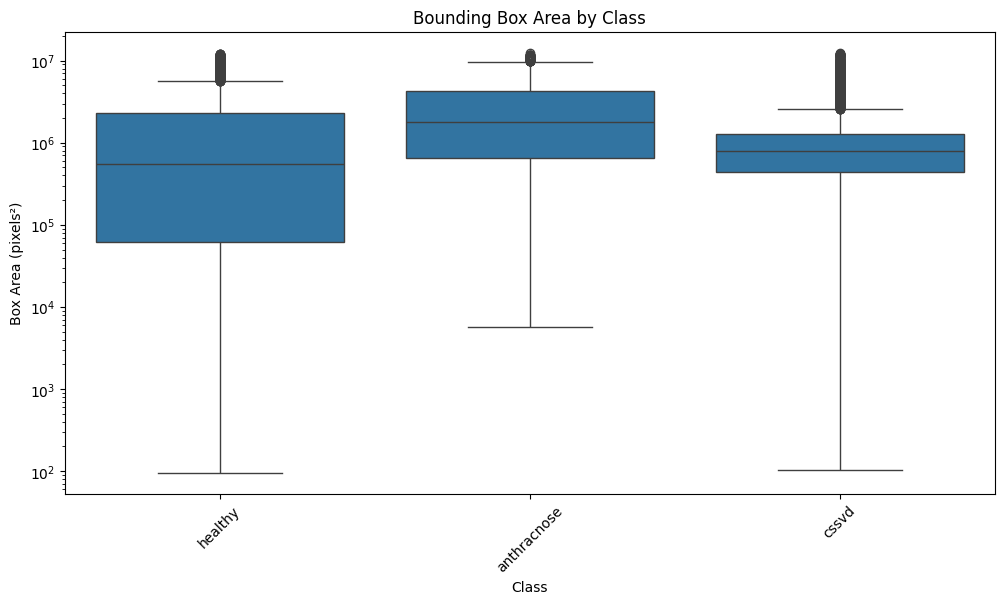

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='class', y='box_area', data=train_df)
plt.title('Bounding Box Area by Class')
plt.xlabel('Class')
plt.ylabel('Box Area (pixels²)')
plt.yscale('log')
plt.xticks(rotation=45)
plt.show()